# PROYECTO INTEGRADOR: Fuga de Clientes con Segmentación de Valor (Customer Churn)
## Cuaderno 01: Análisis Exploratorio de Datos (EDA) Orientado a Preguntas de Negocio
**Curso:** Data Mining Tools (CC209) — UPC  
**Fase:** Trabajo Parcial (TP1) — Semana 7  
**Docente:** Carlos Fernando Montoya Cubas  

---

### 1. Contexto del Problema y Preguntas de Investigación
La fuga de clientes (*churn*) es un problema recurrente en los servicios por suscripción: cada cliente que cancela representa facturación recurrente que se pierde, y las campañas de retención indiscriminadas sobre toda la cartera resultan costosas. Este contexto se usa como motivación del proyecto; el dataset no permite medir costos de adquisición ni de retención.

Este análisis exploratorio busca responder cuatro preguntas concretas de negocio:
1. **¿Qué tipo de compromiso contractual presenta mayor vulnerabilidad de fuga?**
2. **¿Existe una ventana crítica temporal de deserción temprana durante los primeros meses del cliente?**
3. **¿Cómo interactúan los cargos mensuales elevados con la falta de servicios de valor agregado (soporte técnico)?**
4. **¿Existen problemas de calidad de datos, inconsistencias de tipado o valores anómalos que condicionen el preprocesamiento?**

> **Principio de evaluación aplicado:** En cada sección se distingue explícitamente entre **"Lo que los datos muestran"** (evidencia cuantitativa) y **"Lo que el equipo interpreta"** (análisis crítico e implicancia estratégica).

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 2. Carga del Dataset y Verificación Estructural
Se utiliza el dataset público de **Telco Customer Churn (IBM)**.

In [2]:
# Carga de datos desde la ruta raw
data_path = Path('../data/raw/telco_customer_churn.csv')
if not data_path.exists():
    data_path = Path('data/raw/telco_customer_churn.csv')

df_raw = pd.read_csv(data_path)
print(f"Dimensiones del dataset: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head()

Dimensiones del dataset: 7043 filas x 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Diagnóstico de Calidad de Datos e Inconsistencias
Identificamos anomalías en tipos de datos, valores nulos y registros con espacios en blanco.

In [3]:
# Resumen de tipos de datos y nulos
info_df = pd.DataFrame({
    'Tipo': df_raw.dtypes,
    'Valores Nulos': df_raw.isnull().sum(),
    'Valores Unicos': df_raw.nunique()
})
print("Resumen de variables:")
print(info_df)

Resumen de variables:
                     Tipo  Valores Nulos  Valores Unicos
customerID            str              0            7043
gender                str              0               2
SeniorCitizen       int64              0               2
Partner               str              0               2
Dependents            str              0               2
tenure              int64              0              73
PhoneService          str              0               2
MultipleLines         str              0               3
InternetService       str              0               3
OnlineSecurity        str              0               3
OnlineBackup          str              0               3
DeviceProtection      str              0               3
TechSupport           str              0               3
StreamingTV           str              0               3
StreamingMovies       str              0               3
Contract              str              0               3
Paperless

#### Hallazgo Crítico de Calidad: `TotalCharges` almacenado como `object`
Al examinar `TotalCharges`, observamos que está tipificado como texto (`object`) a pesar de ser un importe monetario.

In [4]:
# Detección de cadenas vacías o espacios en TotalCharges
blank_mask = df_raw['TotalCharges'].str.strip() == ''
print(f"Cantidad de registros con espacios en blanco en TotalCharges: {blank_mask.sum()}")
display_blank = df_raw.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
print(display_blank)

Cantidad de registros con espacios en blanco en TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


> **Lo que los datos muestran:**
> Los 11 registros donde `TotalCharges` contiene espacios en blanco tienen exactamente `tenure = 0` (antigüedad de 0 meses) y ninguno de ellos ha cancelado (`Churn = 'No'`).
>
> **Lo que el grupo interpreta:**
> Se trata de clientes recién dados de alta en el sistema que aún no han cerrado su primer ciclo de facturación. No representan datos corruptos ni pérdida aleatoria de información, sino una lógica de negocio donde el acumulado histórico es \$0. La decisión metodológica fundamentada es convertir `' '` a `NaN` y reemplazarlo por 0 en el flujo de preparación, transformando la variable a `float64`.

In [5]:
# Corrección preliminar para fines de visualización en el EDA
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
df['Churn_Binario'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Variable TotalCharges convertida a numérica exitosamente.")

Variable TotalCharges convertida a numérica exitosamente.


#### Duplicados, categorías y valores extremos
Se completa el diagnóstico de calidad con tres verificaciones: registros duplicados, consistencia de las categorías y valores extremos en las variables numéricas.

In [6]:
# 1. Duplicados
print("Filas duplicadas completas:", df_raw.duplicated().sum())
print("customerID repetidos:", df_raw['customerID'].duplicated().sum())
print("Filas idénticas al excluir customerID:", df_raw.drop(columns='customerID').duplicated().sum())

# 2. Categorías observadas en cada variable categórica
print()
cat_cols = [c for c in df_raw.columns if c not in ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]
for c in cat_cols:
    print(f"{c}: {sorted(df_raw[c].unique().tolist())}")

# 3. Redundancia entre categorías
servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
sin_internet = df_raw['InternetService'] == 'No'
coincide_internet = all(((df_raw[s] == 'No internet service') == sin_internet).all() for s in servicios)
sin_telefono = df_raw['PhoneService'] == 'No'
coincide_telefono = ((df_raw['MultipleLines'] == 'No phone service') == sin_telefono).all()
print()
print(f"Clientes sin internet: {sin_internet.sum()} | 'No internet service' coincide en los 6 servicios: {coincide_internet}")
print(f"Clientes sin telefonía: {sin_telefono.sum()} | 'No phone service' coincide con PhoneService = No: {coincide_telefono}")

Filas duplicadas completas: 0
customerID repetidos: 0
Filas idénticas al excluir customerID: 22

gender: ['Female', 'Male']
SeniorCitizen: [0, 1]
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn: ['No', 'Yes']

Clientes sin internet: 1526 | 'No internet service' coincide en los 6 servicios: True
Clientes sin telefonía: 682 | 'No phone service' coincide con PhoneS

In [7]:
# 4. Valores extremos por criterio IQR (1.5 x rango intercuartílico)
filas = []
for c in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filas.append({
        'variable': c,
        'min': df[c].min(),
        'max': df[c].max(),
        'lim_inf_IQR': round(lim_inf, 2),
        'lim_sup_IQR': round(lim_sup, 2),
        'fuera_de_limites': int(((df[c] < lim_inf) | (df[c] > lim_sup)).sum()),
        'asimetria': round(df[c].skew(), 2)
    })
print(pd.DataFrame(filas).to_string(index=False))

# 5. Regla lógica: TotalCharges debería aproximarse a tenure x MonthlyCharges
esperado = df['tenure'] * df['MonthlyCharges']
con_antiguedad = df['tenure'] > 0
dif_rel = ((df['TotalCharges'] - esperado).abs() / esperado)[con_antiguedad]
print()
print(f"Correlación entre TotalCharges y tenure x MonthlyCharges: {np.corrcoef(esperado, df['TotalCharges'])[0, 1]:.4f}")
print(f"Diferencia relativa mediana: {dif_rel.median():.1%} | percentil 95: {dif_rel.quantile(0.95):.1%}")

      variable   min     max  lim_inf_IQR  lim_sup_IQR  fuera_de_limites  asimetria
        tenure  0.00   72.00       -60.00       124.00                 0       0.24
MonthlyCharges 18.25  118.75       -46.02       171.38                 0      -0.22
  TotalCharges  0.00 8684.80     -4683.52      8868.67                 0       0.96

Correlación entre TotalCharges y tenure x MonthlyCharges: 0.9996
Diferencia relativa mediana: 2.0% | percentil 95: 10.3%


> **Lo que los datos muestran:**
> 1. No hay filas duplicadas completas ni `customerID` repetidos. Existen 22 filas idénticas a otra cuando se excluye el identificador.
> 2. Las categorías no presentan variantes de escritura (mayúsculas, espacios o sinónimos). Los 1,526 clientes sin internet figuran como `No internet service` en los seis servicios adicionales, y los 682 clientes sin telefonía figuran como `No phone service` en `MultipleLines`.
> 3. Ninguna de las tres variables numéricas tiene valores fuera de los límites IQR. `TotalCharges` presenta asimetría positiva (0.96).
> 4. `TotalCharges` es casi igual a `tenure` × `MonthlyCharges` (correlación de 0.9996; diferencia relativa mediana de 2.0%).
>
> **Lo que el grupo interpreta:**
> Las 22 coincidencias no se consideran duplicados: con variables mayormente categóricas es esperable que clientes distintos compartan el mismo perfil, y cada uno tiene su propio identificador; por ello no se eliminan. Las categorías `No internet service` y `No phone service` no son errores, pero sí información redundante con `InternetService` y `PhoneService`, lo que genera columnas colineales tras el One-Hot Encoding; se conservan en el TP1 y su consolidación queda como mejora para el TF1. Al no hallarse valores extremos, no se recorta ni se transforma ninguna variable numérica. La casi identidad entre `TotalCharges` y `tenure` × `MonthlyCharges` confirma la coherencia de los datos y advierte de multicolinealidad entre las tres variables numéricas, relevante para interpretar los coeficientes de la Regresión Logística.

### 4. Análisis de la Variable Objetivo (`Churn`)
Evaluamos el balance de clases para justificar las métricas posteriores.

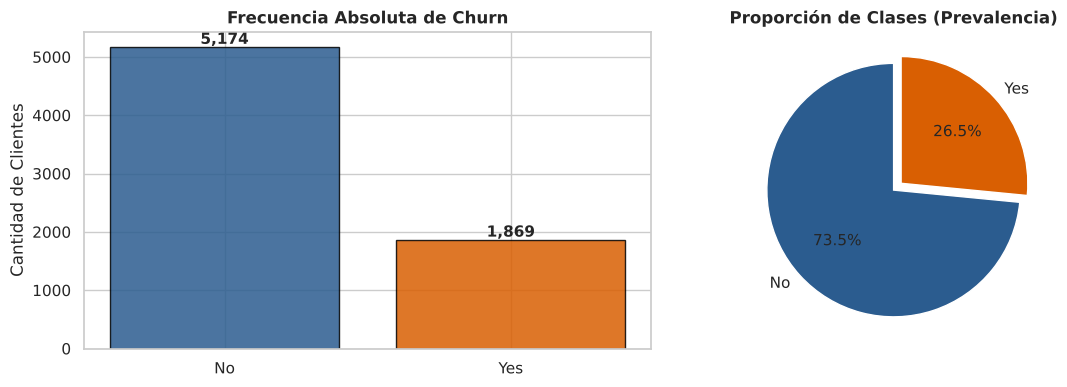

In [8]:
churn_counts = df['Churn'].value_counts()
churn_rates = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2b5c8f', '#d95f02']

ax[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', alpha=0.85)
ax[0].set_title('Frecuencia Absoluta de Churn', fontweight='bold')
ax[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(churn_counts.values):
    ax[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

ax[1].pie(churn_rates.values, labels=churn_rates.index, autopct='%.1f%%', colors=colors, startangle=90, explode=(0, 0.08))
ax[1].set_title('Proporción de Clases (Prevalencia)', fontweight='bold')

plt.tight_layout()
plt.show()

> **Lo que los datos muestran:**
> El 26.54% de la base (1,869 clientes) ha cancelado el servicio, frente al 73.46% (5,174) que permanece activo. Existe una relación de desbalance de aproximadamente 2.8 a 1.
>
> **Lo que el grupo interpreta:**
> Un modelo trivial que prediga siempre la clase mayoritaria obtendría un 73.5% de Accuracy pero capturaría 0 desertores, provocando pérdidas financieras severas. Por ello, la evaluación **no puede depender de Accuracy**, sino de **PR-AUC, Recall de la clase 1 y el análisis de la curva Costo-Beneficio**.

### 5. Pregunta 1: ¿Qué tipo de compromiso contractual presenta mayor tasa de fuga?

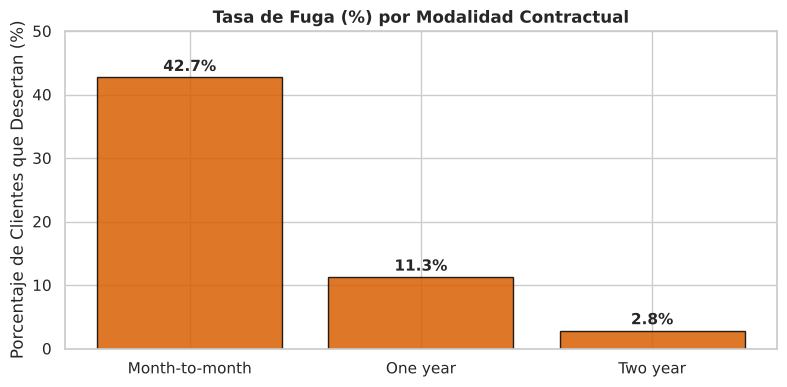

In [9]:
contract_churn = df.groupby('Contract')['Churn_Binario'].agg(['count', 'mean']).reset_index()
contract_churn['Tasa_Churn_%'] = contract_churn['mean'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contract_churn['Contract'], contract_churn['Tasa_Churn_%'], color='#d95f02', edgecolor='black', alpha=0.85)
ax.set_title('Tasa de Fuga (%) por Modalidad Contractual', fontweight='bold')
ax.set_ylabel('Porcentaje de Clientes que Desertan (%)')
ax.set_ylim(0, 50)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

> **Lo que los datos muestran:**
> Los contratos mes a mes (*Month-to-month*) presentan una tasa de deserción del **42.7%**, mientras que los contratos a un año caen al **11.3%** y a dos años a un mínimo del **2.8%**.
>
> **Lo que el grupo interpreta:**
> La modalidad de contratación es la variable estructurante del riesgo. La ausencia de barreras de salida facilita la fuga inmediata ante cualquier insatisfacción. Como implicancia, las políticas de retención deben enfocarse prioritariamente en incentivar la migración de clientes hacia contratos anuales mediante planes promocionales.

### 6. Pregunta 2: ¿Existe una ventana crítica temporal de deserción temprana?

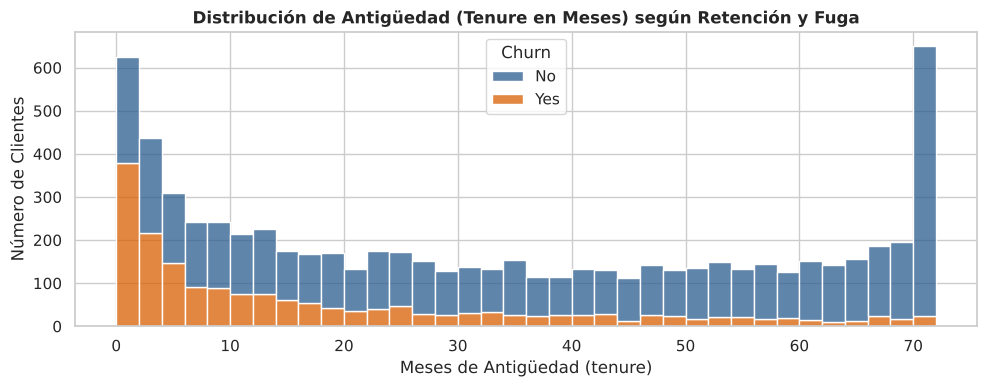

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=36, multiple='stack', palette=['#2b5c8f', '#d95f02'], ax=ax)
ax.set_title('Distribución de Antigüedad (Tenure en Meses) según Retención y Fuga', fontweight='bold')
ax.set_xlabel('Meses de Antigüedad (tenure)')
ax.set_ylabel('Número de Clientes')
plt.tight_layout()
plt.show()

In [11]:
# Tasa de fuga por tramos de antigüedad
tramos = pd.cut(
    df['tenure'],
    bins=[-1, 5, 12, 24, 48, 72],
    labels=['0-5', '6-12', '13-24', '25-48', '49-72']
)
tenure_churn = (
    df.groupby(tramos, observed=True)['Churn_Binario']
    .agg(clientes='count', fugas='sum', tasa_churn='mean')
)
tenure_churn['tasa_churn'] = (tenure_churn['tasa_churn'] * 100).round(1)
print(tenure_churn)

        clientes  fugas  tasa_churn
tenure                             
0-5         1371    744        54.3
6-12         815    293        36.0
13-24       1024    294        28.7
25-48       1594    325        20.4
49-72       2239    213         9.5


> **Lo que los datos muestran:**
> La mayor concentración de fugas ocurre en los **primeros 5 meses de vida del cliente**, alcanzando su pico en el mes 1. Por tramos de antigüedad, la tasa de fuga es de 54.3% entre 0 y 5 meses, 36.0% entre 6 y 12, 28.7% entre 13 y 24, 20.4% entre 25 y 48 y 9.5% entre 49 y 72 meses.
>
> **Lo que el grupo interpreta:**
> La compañía sufre un fenómeno de "fuga por fricción inicial" (*onboarding failure*). Si un cliente supera el primer semestre, su probabilidad de permanencia aumenta drásticamente. Esto fundamenta nuestro **Baseline Heurístico de Negocio**: clientes con contrato mensual y antigüedad $\le 6$ meses representan el núcleo de mayor deserción predecible.

### 7. Pregunta 3: ¿Cómo interactúan los cargos mensuales elevados y el servicio de soporte técnico?

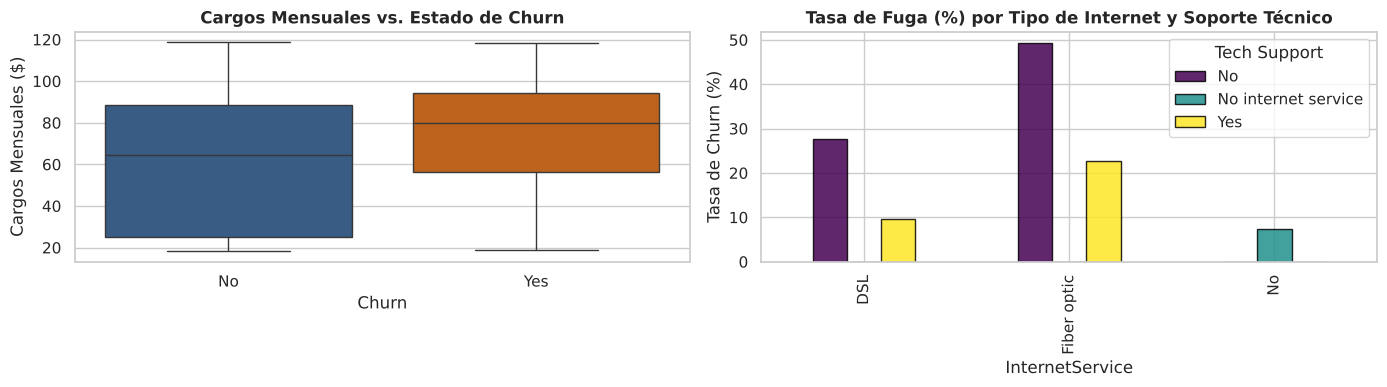

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2b5c8f', '#d95f02'], ax=ax[0])
ax[0].set_title('Cargos Mensuales vs. Estado de Churn', fontweight='bold')
ax[0].set_ylabel('Cargos Mensuales ($)')

# Churn rate por combinación de Internet y TechSupport
support_summary = df.groupby(['InternetService', 'TechSupport'])['Churn_Binario'].mean().unstack() * 100
support_summary.plot(kind='bar', ax=ax[1], colormap='viridis', edgecolor='black', alpha=0.85)
ax[1].set_title('Tasa de Fuga (%) por Tipo de Internet y Soporte Técnico', fontweight='bold')
ax[1].set_ylabel('Tasa de Churn (%)')
ax[1].legend(title='Tech Support')

plt.tight_layout()
plt.show()

> **Lo que los datos muestran:**
> 1. Los clientes que desertan pagan significativamente más en promedio (mediana cercana a \$80/mes) que aquellos que permanecen (mediana de \$65/mes).
> 2. Los clientes con **Fibra Óptica que NO cuentan con Soporte Técnico** presentan una alarmante tasa de fuga del **49.4%**. Entre los clientes de fibra óptica que sí cuentan con soporte técnico, la tasa es de 22.6%.
>
> **Lo que el grupo interpreta:**
> La fibra óptica es el servicio más costoso y genera mayores expectativas de rendimiento técnico. Al sufrir fallas sin respaldo de soporte técnico, el cliente percibe una relación costo-beneficio negativa y rescinde el contrato. La inclusión de soporte técnico bonificado en planes de fibra surge como una hipótesis a evaluar. Esta diferencia es una asociación: los datos no permiten afirmar que otorgar soporte técnico reduzca la fuga, pues quienes lo contratan pueden diferir en otras características.

### 8. Pregunta 4: ¿Incide el canal de cobro en la probabilidad de cancelación?

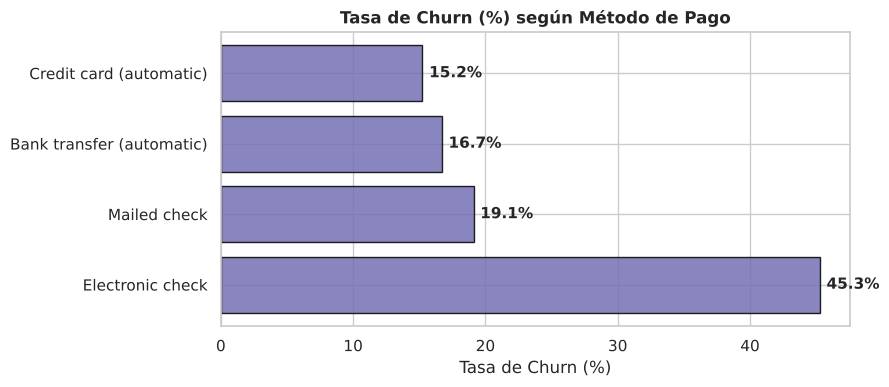

In [13]:
pay_churn = df.groupby('PaymentMethod')['Churn_Binario'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(pay_churn.index, pay_churn.values, color='#7570b3', edgecolor='black', alpha=0.85)
ax.set_title('Tasa de Churn (%) según Método de Pago', fontweight='bold')
ax.set_xlabel('Tasa de Churn (%)')
for bar in bars:
    wval = bar.get_width()
    ax.text(wval + 0.5, bar.get_y() + bar.get_height()/2, f'{wval:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

> **Lo que los datos muestran:**
> El método de pago con cheque electrónico (*Electronic check*) presenta una tasa de deserción de 45.3%, frente a 19.1% del cheque por correo, 16.7% de la transferencia bancaria automática y 15.2% de la tarjeta de crédito automática.
>
> **Lo que el grupo interpreta:**
> El cheque electrónico obliga a una acción manual de pago mensual, renovando la decisión consciente de gasto en cada período. En contraste, los pagos automáticos reducen la fricción cognitiva de renovación. Es una hipótesis del grupo, no una relación causal demostrada.

### 9. Síntesis del EDA y Decisiones que Condicionan el Preprocesamiento (TP1)

A partir de la evidencia recabada:
1. **Exclusión de Identificadores:** Se elimina `customerID` para evitar fugas y memorización inútil.
2. **Tratamiento de `TotalCharges`:** Imputación de 0 para clientes nuevos (`tenure = 0`) y conversión formal a variable de punto flotante.
3. **Escalamiento Numérico:** Se utilizará `StandardScaler` en `tenure`, `MonthlyCharges` y `TotalCharges` para compatibilidad con modelos lineales y de regularización.
4. **Codificación Categórica:** Se aplicará `OneHotEncoder(drop='first')` sobre variables nominales como `Contract`, `InternetService` y `PaymentMethod` para no inducir relaciones ordinales artificiales ni multicolinealidad estricta.
5. **Estrategia de Partición:** Partición estratificada 70% Train / 15% Validation / 15% Test para preservar la tasa de 26.5% de Churn en los tres conjuntos, ajustando el preprocesador **únicamente** sobre los datos de entrenamiento.
6. **Duplicados, categorías y valores extremos:** No se eliminan filas ni se recortan valores, porque no se hallaron identificadores repetidos, categorías mal escritas ni valores fuera de los límites IQR. Las categorías `No internet service` y `No phone service` son redundantes con `InternetService` y `PhoneService`; se conservan en el TP1 y su consolidación se evaluará en el TF1.